# Plot de IMUs do RobotEmotions (direto dos CSVs)

Este notebook permite escolher a captura por `dominio`, `user` e `tag`, e plotar somente um subconjunto de sensores.

Ordem dos sensores no CSV:
1. `waist`
2. `head_left`
3. `right_forearm`
4. `left_forearm`

In [3]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

# Ajuste aqui o caminho raiz do dataset se necessario
DATASET_ROOT = Path('../data/RobotEmotions')

# Variaveis de selecao da captura
DOMINIO = '10ms'
USER = 2
TAG = 1

# Escolha um subconjunto de sensores (nomes validos abaixo)
SENSOR_ORDER = ['waist', 'head_left', 'right_forearm', 'left_forearm']
SENSORES_SELECIONADOS = ['right_forearm', 'left_forearm']

# Canais para plotar por sensor
MODALIDADES = ['acc', 'gyro']

# Janela opcional de amostras; use None para plotar tudo
START_IDX = 0
END_IDX = None

In [4]:
def listar_opcoes(dataset_root: Path):
    dominios = sorted([p.name for p in dataset_root.iterdir() if p.is_dir()])
    opcoes = {}
    for dominio in dominios:
        dominio_dir = dataset_root / dominio
        users = sorted(
            int(m.group(1))
            for p in dominio_dir.iterdir()
            if p.is_dir() and (m := re.match(r'^User(\d+)$', p.name, flags=re.IGNORECASE))
        )
        opcoes[dominio] = {}
        for user in users:
            user_dir = dominio_dir / f'User{user}'
            tags = sorted(
                int(m.group(1))
                for p in user_dir.iterdir()
                if p.is_dir() and (m := re.match(r'^Tag(\d+)$', p.name, flags=re.IGNORECASE))
            )
            opcoes[dominio][user] = tags
    return opcoes

def caminho_csv(dataset_root: Path, dominio: str, user: int, tag: int) -> Path:
    tag_dir = dataset_root / dominio / f'User{user}' / f'Tag{tag}'
    esperado = tag_dir / f'ESP_{user}_{tag}.csv'
    if esperado.exists():
        return esperado

    candidatos = sorted(tag_dir.glob('ESP*.csv'))
    if not candidatos:
        raise FileNotFoundError(f'Nenhum CSV encontrado em: {tag_dir}')
    return candidatos[0]

opcoes = listar_opcoes(DATASET_ROOT)
print('Dominios disponiveis:', list(opcoes.keys()))
if DOMINIO in opcoes:
    print(f'Users em {DOMINIO}:', list(opcoes[DOMINIO].keys()))
    if USER in opcoes[DOMINIO]:
        print(f'Tags para User{USER}:', opcoes[DOMINIO][USER])

csv_path = caminho_csv(DATASET_ROOT, DOMINIO, USER, TAG)
print('CSV selecionado:', csv_path)

Dominios disponiveis: ['10ms', '30ms']
Users em 10ms: [2, 3, 4, 5]
Tags para User2: [1, 5, 6, 7, 9, 10, 11, 16, 17, 18]
CSV selecionado: ../data/RobotEmotions/10ms/User2/Tag1/ESP_2_1.csv


In [5]:
df = pd.read_csv(csv_path)

timestamp_cols = [c for c in df.columns if c.lower().startswith('timestamp')]
if not timestamp_cols:
    raise ValueError('Nao encontrei coluna de timestamp no CSV.')

t = pd.to_numeric(df[timestamp_cols[0]], errors='coerce')
t = (t - t.iloc[0]) / 1000.0

sensor_to_idx = {nome: i + 1 for i, nome in enumerate(SENSOR_ORDER)}
invalidos = [s for s in SENSORES_SELECIONADOS if s not in sensor_to_idx]
if invalidos:
    raise ValueError(f'Sensores invalidos: {invalidos}. Validos: {list(sensor_to_idx.keys())}')

if END_IDX is None:
    view = slice(START_IDX, None)
else:
    view = slice(START_IDX, END_IDX)

print('Colunas totais:', len(df.columns))
print('Primeiras colunas:', list(df.columns[:12]))

Colunas totais: 38
Primeiras colunas: ['timestamp', 'acc_X_1', 'acc_Y_1', 'acc_Z_1', 'gyro_X_1', 'gyro_Y_1', 'gyro_Z_1', 'pitch_1', 'roll_1', 'yaw_1', 'acc_X_2', 'acc_Y_2']


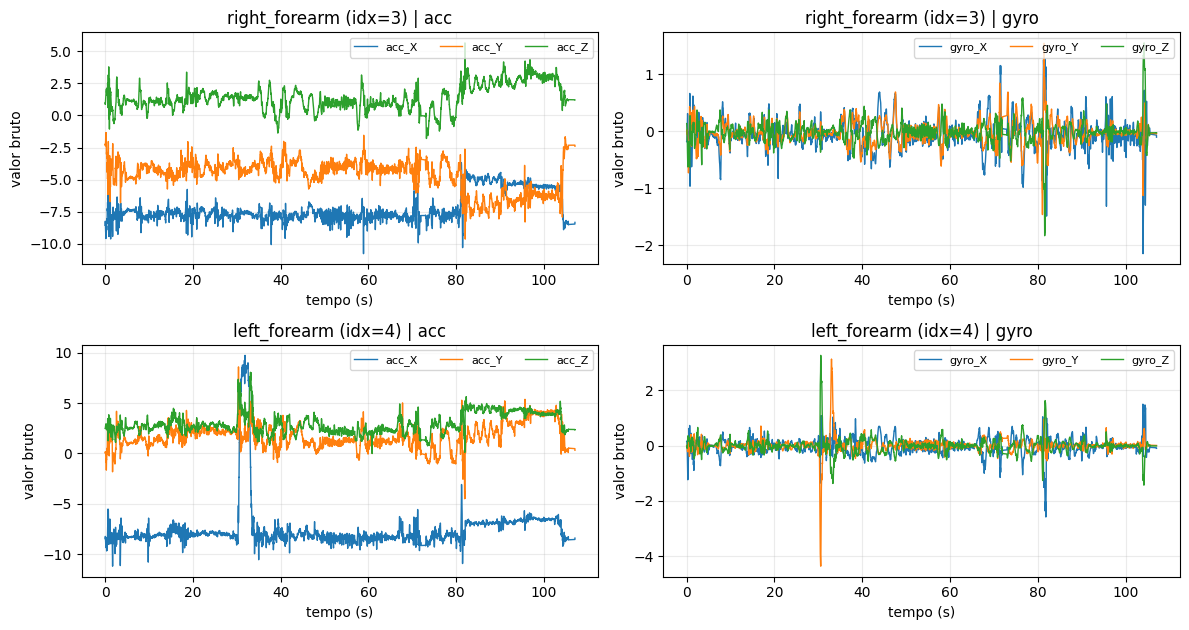

In [6]:
modalidades_validas = {'acc': ('X', 'Y', 'Z'), 'gyro': ('X', 'Y', 'Z')}

n_rows = len(SENSORES_SELECIONADOS)
n_cols = len(MODALIDADES)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 3.2 * n_rows), squeeze=False)

for i, sensor_nome in enumerate(SENSORES_SELECIONADOS):
    sensor_idx = sensor_to_idx[sensor_nome]

    for j, mod in enumerate(MODALIDADES):
        ax = axes[i, j]
        if mod not in modalidades_validas:
            ax.set_title(f'{sensor_nome} | modalidade invalida: {mod}')
            ax.axis('off')
            continue

        axes_names = modalidades_validas[mod]
        plotted = False
        for eixo in axes_names:
            col = f'{mod}_{eixo}_{sensor_idx}'
            if col in df.columns:
                y = pd.to_numeric(df[col], errors='coerce')
                ax.plot(t.iloc[view], y.iloc[view], label=f'{mod}_{eixo}', linewidth=1.0)
                plotted = True

        ax.set_title(f'{sensor_nome} (idx={sensor_idx}) | {mod}')
        ax.set_xlabel('tempo (s)')
        ax.set_ylabel('valor bruto')
        ax.grid(alpha=0.25)

        if plotted:
            ax.legend(loc='upper right', ncol=3, fontsize=8)
        else:
            ax.text(0.5, 0.5, 'Sem colunas para este sensor/modalidade', ha='center', va='center')

plt.tight_layout()
plt.show()